In [167]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [168]:
#parametros

a = 1 
b = 0.1
d = 0.075
g = 1.5

#condicoes iniciais 

x0 = 10
y0 = 5

#tempo  passo de tempo
tf = 10 #tempo final 
h = 0.1 #passo de tempo 
t = np.arange(0, tf+h, h) #array com os pontos de tempo


In [169]:
def sistemaDeEquacoes(estado):
    x, y = estado
    dxdt = a*x - b*y*x #presa
    dydt = d*x*y - g*y #predador
    return np.array([dxdt, dydt])

In [170]:
def metodoDeEuler(funcao,y0,t,h):
    n = len(t)
    solucaoEuler = np.zeros((n,len(y0))) # Matriz para armazenar as soluções com dimensão (n, 2)
    solucaoEuler[0] = y0
    for i in range(n-1):
        derivadas = funcao(solucaoEuler[i])
        solucaoEuler[i+1] = solucaoEuler[i] + h * derivadas

    return solucaoEuler

In [171]:
def metodoDeRungeKutta(funcao,y0,t,h):
    n = len(t)
    solucaoRK = np.zeros((n,len(y0)))
    solucaoRK[0] = y0 
    for i in range(n-1):
        k1 = funcao(solucaoRK[i])
        k2 = funcao(solucaoRK[i] + 0.5*h*k1)
        k3 = funcao(solucaoRK[i] + 0.5*h*k2)
        k4 = funcao(solucaoRK[i] + h*k3)
        solucaoRK[i+1] = solucaoRK[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

    return solucaoRK

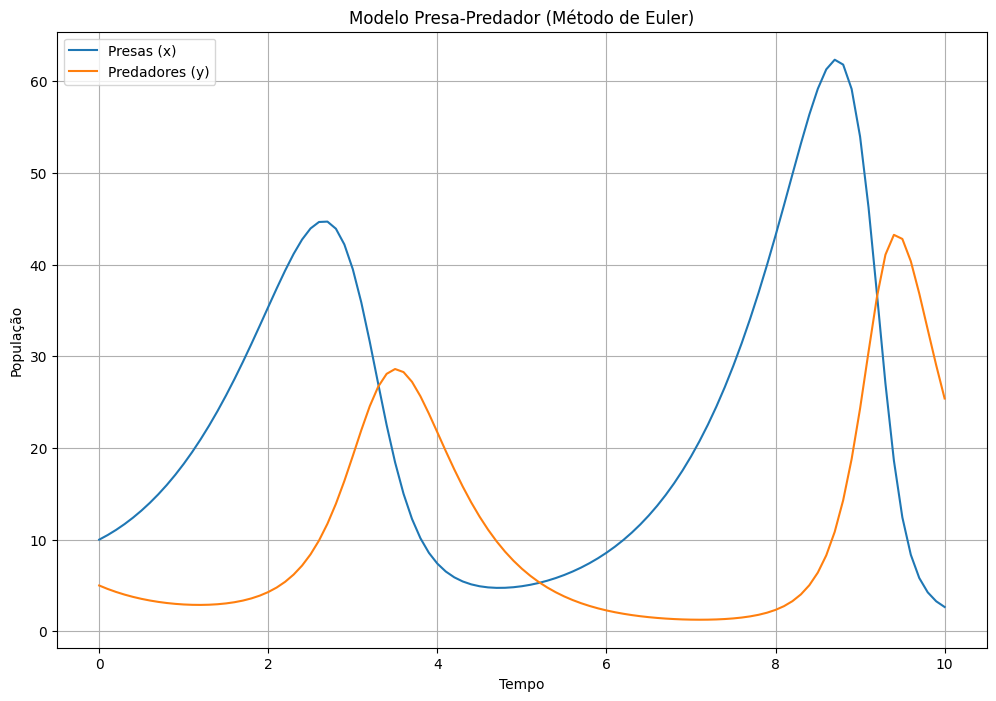

In [ ]:
solucao = metodoDeEuler(sistemaDeEquacoes, [x0, y0], t, h)

plt.figure(figsize=(12,8))
plt.plot(t, solucao[:,0], label='Presas (x)') #solucao[:,0] = todas as presas ao longo do tempo para cada tempo t
plt.plot(t, solucao[:,1], label='Predadores (y)') #solucao[:,1] = todos os predadores ao longo do tempo para cada tempo t

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title('Modelo Presa-Predador (Método de Euler)')

plt.grid(True)
plt.legend()comprimento
plt.show()

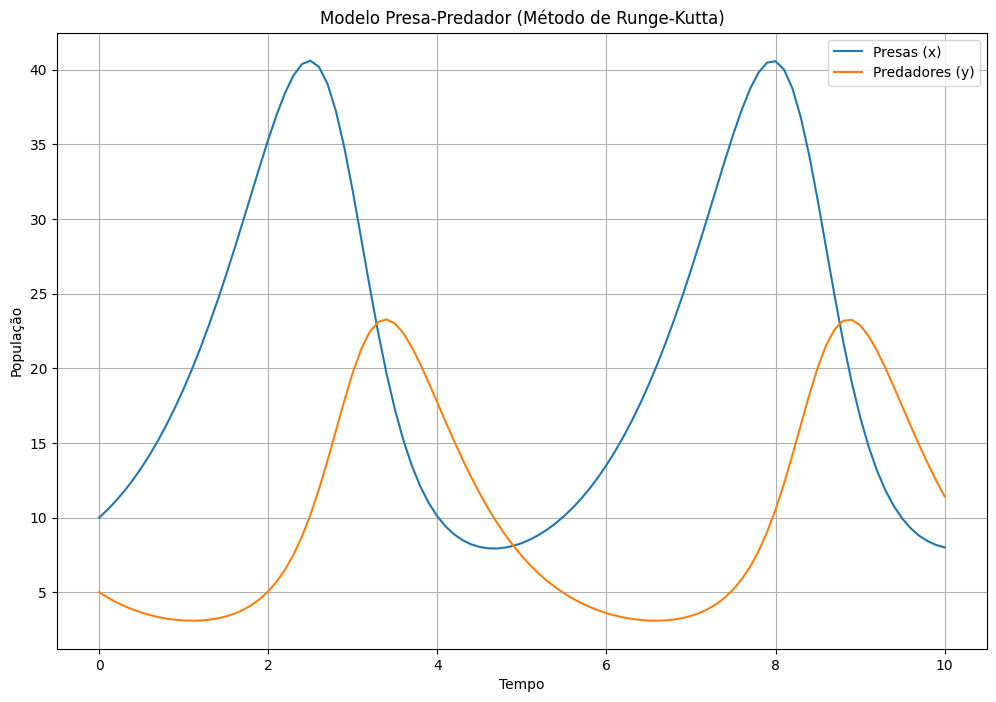

In [ ]:
solucao = metodoDeRungeKutta(sistemaDeEquacoes, [x0, y0], t, h)

plt.figure(figsize=(12,8))
plt.plot(t, solucao[:,0], label='Presas (x)')
plt.plot(t, solucao[:,1], label='Predadores (y)')

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title('Modelo Presa-Predador (Método de Runge-Kutta)')

plt.grid(True)
plt.legend()
plt.show()  

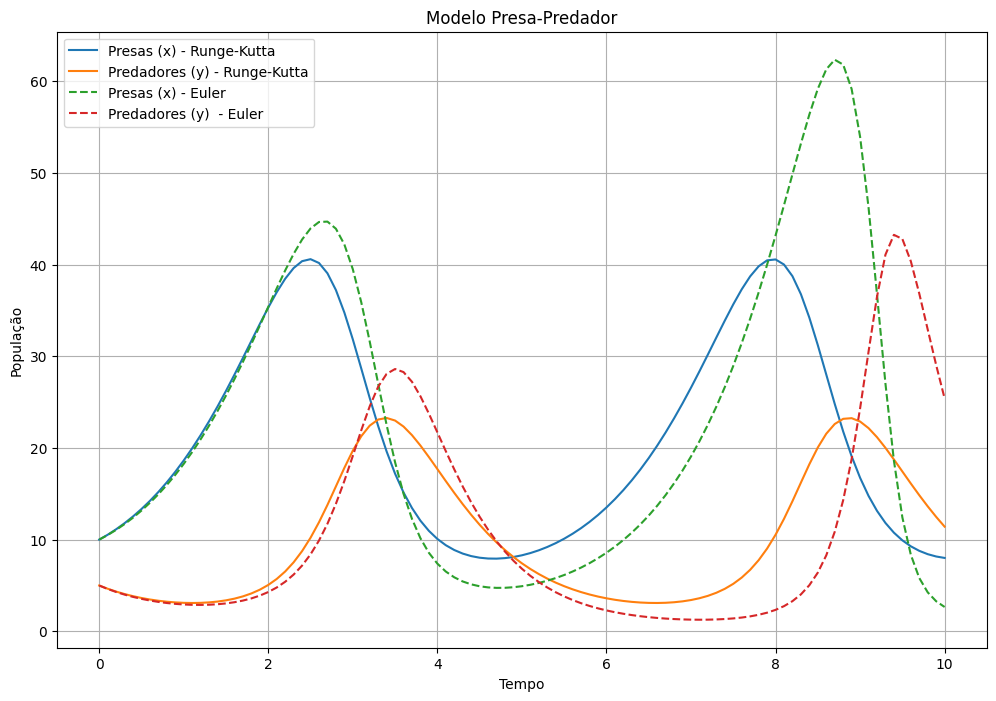

In [ ]:
solucaoRungeKutta = metodoDeRungeKutta(sistemaDeEquacoes, [x0, y0], t, h)
solucaoEuller = metodoDeEuler(sistemaDeEquacoes,[x0, y0], t, h)

plt.figure(figsize=(12,8))
plt.plot(t, solucaoRungeKutta[:,0], label='Presas (x) - Runge-Kutta')
plt.plot(t, solucaoRungeKutta[:,1], label='Predadores (y) - Runge-Kutta')
plt.plot(t, solucaoEuller[:,0], label='Presas (x) - Euler' , linestyle = '--')
plt.plot(t, solucaoEuller[:,1], label='Predadores (y)  - Euler'  , linestyle = '--')

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title('Modelo Presa-Predador')

plt.grid(True)
plt.legend()
plt.show()  



In [175]:
dados = {
    't': t,
    'Presas RK': solucaoRungeKutta[:,0],
    'Predadores RK' : solucaoRungeKutta[:,1] , 
    'Presas Euler': solucaoEuller[:,0],
    'Predadores Euler' : solucaoEuller[:,1] , 
}

df = pd.DataFrame(dados)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df

,t,Presas RK,Predadores RK,Presas Euler,Predadores Euler
0,0.0,10.000000,5.000000,10.000000,5.000000
1,0.1,10.531635,4.647790,10.500000,4.625000
2,0.2,11.128235,4.338701,11.064375,4.295469
3,0.3,11.792657,4.069357,11.695546,4.007599
4,0.4,12.528120,3.836815,12.396390,3.757992
5,0.5,13.338124,3.638579,13.170173,3.543684
6,0.6,14.226359,3.472623,14.020481,3.362164
7,0.7,15.196597,3.337406,14.951138,3.211383
8,0.8,16.252543,3.231911,15.966114,3.089779
9,0.9,17.397661,3.155684,17.069407,2.996300
